## Task #2 - Predict Future Stock Prices (Short-Term)  

`Objective`  

Use historical stock data to predict the next day's closing price.  

`Dataset`

Stock market data from Yahoo Finance (retrieved using the yfinance Python library)  

-----------------

## Problem Statement

Predicting short-term stock price movements is challenging due to market volatility and changing trends. This project aims to analyze historical GOLD stock price data and build a model to predict the next day's closing price.

## Goal

To use historical GOLD stock market data retrieved through the yfinance library, perform data preprocessing and analysis, and develop a machine learning model capable of forecasting the next day's closing price.

-------------------

# Importing Libraries and Dataset

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
gold = "GC=F"

df = yf.download(
    tickers=gold,
    start="2025-06-26",
    end="2026-06-26"
)

[*********************100%***********************]  1 of 1 completed


In [48]:
df


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2025-06-26,3333.500000,3333.500000,3332.399902,3332.399902,2058
2025-06-27,3273.699951,3318.699951,3253.800049,3318.699951,284
2025-06-30,3294.399902,3306.899902,3262.000000,3265.899902,1242
2025-07-01,3336.699951,3354.100098,3310.100098,3310.100098,371
2025-07-02,3348.000000,3357.500000,3329.000000,3329.000000,39
...,...,...,...,...,...
2026-06-12,4215.000000,4225.299805,4173.200195,4208.299805,1167
2026-06-15,4328.000000,4362.000000,4269.100098,4271.200195,1666


# Changing the name of ticker 

In [49]:
df = df.rename(columns={'GC=F': 'Gold'}, level='Ticker')

In [50]:
df

Price,Close,High,Low,Open,Volume
Ticker,Gold,Gold,Gold,Gold,Gold
Date,,,,,
2025-06-26,3333.500000,3333.500000,3332.399902,3332.399902,2058
2025-06-27,3273.699951,3318.699951,3253.800049,3318.699951,284
2025-06-30,3294.399902,3306.899902,3262.000000,3265.899902,1242
2025-07-01,3336.699951,3354.100098,3310.100098,3310.100098,371
2025-07-02,3348.000000,3357.500000,3329.000000,3329.000000,39
...,...,...,...,...,...
2026-06-12,4215.000000,4225.299805,4173.200195,4208.299805,1167
2026-06-15,4328.000000,4362.000000,4269.100098,4271.200195,1666


# Exploring the Dataset

In [51]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,Gold,Gold,Gold,Gold,Gold
Date,,,,,
2025-06-26,3333.500000,3333.500000,3332.399902,3332.399902,2058
2025-06-27,3273.699951,3318.699951,3253.800049,3318.699951,284
2025-06-30,3294.399902,3306.899902,3262.000000,3265.899902,1242
2025-07-01,3336.699951,3354.100098,3310.100098,3310.100098,371
2025-07-02,3348.000000,3357.500000,3329.000000,3329.000000,39


In [52]:
df.shape

(248, 5)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2025-06-26 to 2026-06-18
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, Gold)   248 non-null    float64
 1   (High, Gold)    248 non-null    float64
 2   (Low, Gold)     248 non-null    float64
 3   (Open, Gold)    248 non-null    float64
 4   (Volume, Gold)  248 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.6 KB


In [54]:
df.isnull().sum()

Price   Ticker
Close   Gold      0
High    Gold      0
Low     Gold      0
Open    Gold      0
Volume  Gold      0
dtype: int64

In [55]:
df["Target"] = df["Close"].shift(-1)

In [56]:
df.head(
)

Price,Close,High,Low,Open,Volume,Target
Ticker,Gold,Gold,Gold,Gold,Gold,
Date,,,,,,
2025-06-26,3333.500000,3333.500000,3332.399902,3332.399902,2058,3273.699951
2025-06-27,3273.699951,3318.699951,3253.800049,3318.699951,284,3294.399902
2025-06-30,3294.399902,3306.899902,3262.000000,3265.899902,1242,3336.699951
2025-07-01,3336.699951,3354.100098,3310.100098,3310.100098,371,3348.000000
2025-07-02,3348.000000,3357.500000,3329.000000,3329.000000,39,3331.600098


In [57]:
df = df.dropna()

In [58]:
df.head()

Price,Close,High,Low,Open,Volume,Target
Ticker,Gold,Gold,Gold,Gold,Gold,
Date,,,,,,
2025-06-26,3333.500000,3333.500000,3332.399902,3332.399902,2058,3273.699951
2025-06-27,3273.699951,3318.699951,3253.800049,3318.699951,284,3294.399902
2025-06-30,3294.399902,3306.899902,3262.000000,3265.899902,1242,3336.699951
2025-07-01,3336.699951,3354.100098,3310.100098,3310.100098,371,3348.000000
2025-07-02,3348.000000,3357.500000,3329.000000,3329.000000,39,3331.600098


In [59]:
X = df[["Open","High","Low","Volume"]]
y = df["Target"]

## Splitting data into 20% and 80% for training and testing

In [60]:
split = int(len(df)*0.8)

In [61]:
len(df)

247

In [62]:
split

197

In [63]:
X_train, X_test = X[:split] , X[split:]
y_train, y_test = y[:split] , y[split:]


## Training Model and Doing Predictions

In [64]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
predictions = model.predict(X_test)

In [66]:
print(predictions)

[4811.77173994 4780.91549523 4792.06060093 4747.86642857 4831.34519794
 4823.99578204 4809.99033995 4847.70817732 4803.65019751 4704.42135504
 4756.990989   4739.97061203 4697.88956035 4702.60649742 4619.94162302
 4546.16635262 4625.45265859 4608.80610344 4540.83261716 4588.78689853
 4713.14638176 4740.19439276 4742.569233   4742.76927746 4707.91811706
 4705.61063079 4675.59211679 4553.6151152  4567.91086039 4533.14162791
 4506.40095272 4545.14016094 4548.73706466 4528.42605937 4443.30358183
 4419.73081907 4563.69283089 4487.58500397 4520.98081407 4453.40218144
 4504.55400219 4351.70809685 4320.25860989 4276.303459   4134.46284885
 4144.97116746 4208.75456226 4341.49906242 4353.13479156 4343.23595682]


In [67]:
print(y_test)

Date
2026-04-08    4792.200195
2026-04-09    4761.899902
2026-04-10    4742.399902
2026-04-13    4825.000000
2026-04-14    4800.000000
2026-04-15    4785.399902
2026-04-16    4857.600098
2026-04-17    4806.600098
2026-04-20    4698.399902
2026-04-21    4732.500000
2026-04-22    4705.100098
2026-04-23    4722.299805
2026-04-24    4675.399902
2026-04-27    4591.500000
2026-04-28    4545.200195
2026-04-29    4614.700195
2026-04-30    4629.899902
2026-05-01    4519.500000
2026-05-04    4555.799805
2026-05-05    4681.899902
2026-05-06    4699.799805
2026-05-07    4720.399902
2026-05-08    4718.700195
2026-05-11    4677.600098
2026-05-12    4697.700195
2026-05-13    4678.100098
2026-05-14    4555.799805
2026-05-15    4552.500000
2026-05-18    4506.299805
2026-05-19    4531.299805
2026-05-20    4539.799805
2026-05-21    4521.000000
2026-05-22    4500.399902
2026-05-26    4447.500000
2026-05-27    4499.299805
2026-05-28    4560.500000
2026-05-29    4475.200195
2026-06-01    4489.100098
2026-06

## Visual Representation Of the Prediction

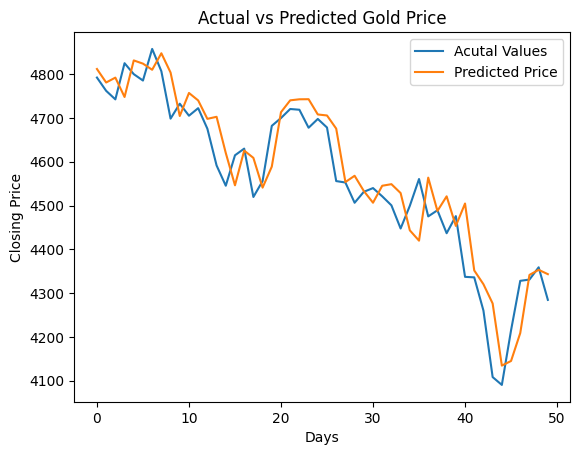

In [68]:
plt.plot(y_test.values, label= "Acutal Values")
plt.plot(predictions, label = "Predicted Price" )
plt.title("Actual vs Predicted Gold Price")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

# Evaluation

In [69]:
mae = mean_absolute_error(y_test,predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 53.00637704098819


In [70]:
rmse = mean_squared_error(
    y_test,
    predictions,
)

print("RMSE:", rmse)

RMSE: 4574.101486343995


In [71]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R² Score:", r2)

R² Score: 0.8674027492904062


## Final Scores:

- R² Score : 86%
- MAE : 53%
- RMSE : 4574

## Results and Final Insights

- Historical GOLD stock data was successfully collected and analyzed.
- The prediction model learned patterns from past price movements to estimate future closing prices.
- Predicted prices generally followed the overall market trend, demonstrating the model's ability to capture short-term price behavior.
- The model's performance depended on the quality and quantity of historical data used for training.
- This project highlighted the usefulness of machine learning in financial forecasting while showing that stock prices remain difficult to predict with complete accuracy due to market uncertainty.